# 오토인코더 실습

module import

In [13]:
#사용할 라이브러리 불러오기
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from matplotlib import pyplot as plt
import numpy as np
import random

In [2]:
# MNIST 데이터셋을 가져온다
training_set, testing_set = mnist.load_data()
X_train, y_train = training_set
X_test, y_test = testing_set

# 신경망에 사용할 수 있게 벡터 형태를 바꾼다
X_train_reshaped = X_train.reshape((X_train.shape[0], X_train.shape[1]*X_train.shape[2]))
X_test_reshaped = X_test.reshape((X_test.shape[0], X_test.shape[1]*X_test.shape[2]))

# 0부터 255까지의 값을 0과 1 사이 값으로 정규화한다
X_train_reshaped = X_train_reshaped/255.
X_test_reshaped = X_test_reshaped/255.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def create_basic_autoencoder(hidden_layer_size):
  model = Sequential()
  model.add(Dense(units=hidden_layer_size, input_shape=(784,), activation='relu'))
  model.add(Dense(units=784, activation='sigmoid'))
  return model

# 은닉 레이어 크기가 다른 오토인코더를 만든다
hiddenLayerSize_1_model = create_basic_autoencoder(hidden_layer_size=1)
hiddenLayerSize_2_model = create_basic_autoencoder(hidden_layer_size=2)
hiddenLayerSize_4_model = create_basic_autoencoder(hidden_layer_size=4)
hiddenLayerSize_8_model = create_basic_autoencoder(hidden_layer_size=8)
hiddenLayerSize_16_model = create_basic_autoencoder(hidden_layer_size=16)
hiddenLayerSize_32_model = create_basic_autoencoder(hidden_layer_size=32)

# 각 오토인코더를 훈련시킨다
hiddenLayerSize_1_model.compile(optimizer='adam', loss='mean_squared_error')
hiddenLayerSize_1_model.fit(X_train_reshaped, X_train_reshaped, epochs=10, verbose=1)

hiddenLayerSize_2_model.compile(optimizer='adam', loss='mean_squared_error')
hiddenLayerSize_2_model.fit(X_train_reshaped, X_train_reshaped, epochs=10, verbose=1)

hiddenLayerSize_4_model.compile(optimizer='adam', loss='mean_squared_error')
hiddenLayerSize_4_model.fit(X_train_reshaped, X_train_reshaped, epochs=10, verbose=1)

hiddenLayerSize_8_model.compile(optimizer='adam', loss='mean_squared_error')
hiddenLayerSize_8_model.fit(X_train_reshaped, X_train_reshaped, epochs=10, verbose=0)

hiddenLayerSize_16_model.compile(optimizer='adam', loss='mean_squared_error')
hiddenLayerSize_16_model.fit(X_train_reshaped, X_train_reshaped, epochs=10, verbose=0)

hiddenLayerSize_32_model.compile(optimizer='adam', loss='mean_squared_error')
hiddenLayerSize_32_model.fit(X_train_reshaped, X_train_reshaped, epochs=10, verbose=0)


모델 테스트 및 시각화

In [ ]:
# 훈련시킨 모델을 사용해 테스트셋의 결과를 예측한다
output_1_model = hiddenLayerSize_1_model.predict(X_test_reshaped)
output_2_model = hiddenLayerSize_2_model.predict(X_test_reshaped)
output_4_model = hiddenLayerSize_4_model.predict(X_test_reshaped)
output_8_model = hiddenLayerSize_8_model.predict(X_test_reshaped)
output_16_model = hiddenLayerSize_16_model.predict(X_test_reshaped)
output_32_model = hiddenLayerSize_32_model.predict(X_test_reshaped)

# 각 모델의 결과를 그려 비교한다
fig, axes = plt.subplots(7, 5, figsize=(15,15))

randomly_selected_imgs = random.sample(range(output_2_model.shape[0]),5)
outputs = [X_test, output_1_model, output_2_model, output_4_model, output_8_model, output_16_model, output_32_model]

# 서브차트를 하나씩 그린다
for row_num, row in enumerate(axes):
  for col_num, ax in enumerate(row):
    ax.imshow(outputs[row_num][randomly_selected_imgs[col_num]].reshape(28,28), cmap='gray')
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

# 오토인코더를 사용한 노이즈 제거

In [5]:
#사용할 라이브러리 불러오기
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from matplotlib import pyplot as plt
import numpy as np
import random

데이터 load 및 전처리

In [6]:
# MNIST 데이터셋을 가져온다
training_set, testing_set = mnist.load_data()
X_train, y_train = training_set
X_test, y_test = testing_set

# 신경망에 사용할 수 있게 벡터 형태를 바꾼다
X_train_reshaped = X_train.reshape((X_train.shape[0], X_train.shape[1]*X_train.shape[2]))
X_test_reshaped = X_test.reshape((X_test.shape[0], X_test.shape[1]*X_test.shape[2]))

# 0부터 255까지의 값을 0과 1 사이 값으로 정규화한다
X_train_reshaped = X_train_reshaped/255.
X_test_reshaped = X_test_reshaped/255.

# MNIST 데이터셋에 노이즈를 추가한다
X_train_noised = X_train_reshaped + np.random.normal(0, 0.5, size=X_train_reshaped.shape)
X_test_noised = X_test_reshaped + np.random.normal(0, 0.5, size=X_test_reshaped.shape)
X_train_noised = np.clip(X_train_noised, a_min=0, a_max=1)
X_test_noised = np.clip(X_test_noised, a_min=0, a_max=1)

In [7]:
def create_basic_autoencoder(hidden_layer_size):
  model = Sequential()
  model.add(Dense(units=hidden_layer_size, input_shape=(784,), activation='relu'))
  model.add(Dense(units=784, activation='sigmoid'))
  return model

# 모델을 만들고 훈련시킨다
basic_denoise_autoencoder = create_basic_autoencoder(hidden_layer_size=32)
basic_denoise_autoencoder.compile(optimizer='adam', loss='mean_squared_error')
basic_denoise_autoencoder.fit(X_train_noised, X_train_reshaped, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0573
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0245
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0218
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0213
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0211
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0210
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0209
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0208
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0207
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0207


테스트 결과 시각화

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


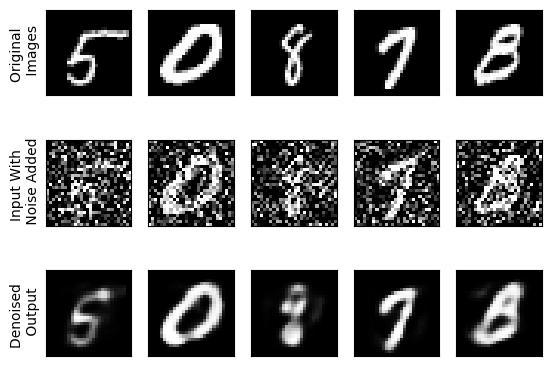

In [8]:
output = basic_denoise_autoencoder.predict(X_test_noised)

# 결과 출력
fig, ((ax1, ax2, ax3, ax4, ax5), (ax6, ax7, ax8, ax9, ax10), (ax11,ax12,ax13,ax14,ax15)) = plt.subplots(3, 5)
randomly_selected_imgs = random.sample(range(output.shape[0]),5)

# 첫 번째 줄에는 원본 이미지를 그린다
for i, ax in enumerate([ax1,ax2,ax3,ax4,ax5]):
  ax.imshow(X_test_reshaped[randomly_selected_imgs[i]].reshape(28,28), cmap='gray')
  if i == 0:
    ax.set_ylabel("Original \n Images")
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])

# 두 번째 줄에는 노이즈를 추가한 이미지를 그린다
for i, ax in enumerate([ax6,ax7,ax8,ax9,ax10]):
  ax.imshow(X_test_noised[randomly_selected_imgs[i]].reshape(28,28), cmap='gray')
  if i == 0:
    ax.set_ylabel("Input With \n Noise Added")
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])

# 세 번째 줄에는 오토인코더가 출력한 결과 이미지를 그린다
for i, ax in enumerate([ax11,ax12,ax13,ax14,ax15]):
  ax.imshow(output[randomly_selected_imgs[i]].reshape(28,28), cmap='gray')
  if i == 0:
    ax.set_ylabel("Denoised \n Output")
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# CNN 기반 오토인코더를 사용한 노이즈 제거

Module import

In [9]:
#사용할 라이브러리 불러오기
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Conv2D
from matplotlib import pyplot as plt
import numpy as np
import random

In [10]:
# MNIST 데이터셋을 가져온다
training_set, testing_set = mnist.load_data()
X_train, y_train = training_set
X_test, y_test = testing_set

# 신경망에 사용할 수 있게 벡터 형태를 바꾼다
X_train_reshaped = X_train.reshape((X_train.shape[0], X_train.shape[1]*X_train.shape[2]))
X_test_reshaped = X_test.reshape((X_test.shape[0], X_test.shape[1]*X_test.shape[2]))

# 0부터 255까지의 값을 0과 1 사이 값으로 정규화한다
X_train_reshaped = X_train_reshaped/255.
X_test_reshaped = X_test_reshaped/255.

# MNIST 데이터셋에 노이즈를 추가한다
X_train_noisy = X_train_reshaped + np.random.normal(0, 0.5, size=X_train_reshaped.shape)
X_test_noisy = X_test_reshaped + np.random.normal(0, 0.5, size=X_test_reshaped.shape)
X_train_noisy = np.clip(X_train_noisy, a_min=0, a_max=1)
X_test_noisy = np.clip(X_test_noisy, a_min=0, a_max=1)

In [11]:
conv_autoencoder = Sequential()
conv_autoencoder.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding='same', input_shape=(28,28,1)))
conv_autoencoder.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding='same'))
conv_autoencoder.add(Conv2D(filters=1, kernel_size=(3,3), activation='sigmoid', padding='same'))
conv_autoencoder.summary()

conv_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
conv_autoencoder.fit(X_train_noisy.reshape(60000,28,28,1), X_train_reshaped.reshape(60000,28,28,1), epochs=2)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 1)           │             145 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 44ms/step - loss: 0.1795
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - loss: 0.1064


결과 시각화

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


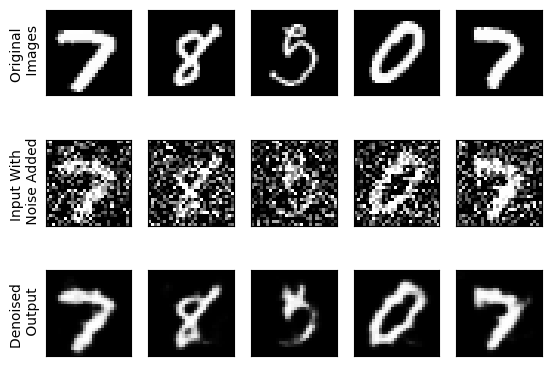

In [12]:
output = conv_autoencoder.predict(X_test_noisy.reshape(10000,28,28,1))

# 결과 출력
fig, ((ax1, ax2, ax3, ax4, ax5), (ax6, ax7, ax8, ax9, ax10), (ax11,ax12,ax13,ax14,ax15)) = plt.subplots(3, 5)
randomly_selected_imgs = random.sample(range(output.shape[0]),5)

# 첫 번째 줄에는 원본 이미지를 그린다
for i, ax in enumerate([ax1,ax2,ax3,ax4,ax5]):
  ax.imshow(X_test_reshaped[randomly_selected_imgs[i]].reshape(28,28), cmap='gray')
  if i == 0:
    ax.set_ylabel("Original \n Images")
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])

# 두 번째 줄에는 노이즈를 추가한 이미지를 그린다
for i, ax in enumerate([ax6,ax7,ax8,ax9,ax10]):
  ax.imshow(X_test_noisy[randomly_selected_imgs[i]].reshape(28,28), cmap='gray')
  if i == 0:
    ax.set_ylabel("Input With \n Noise Added")
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])

# 세 번째 줄에는 오토인코더가 출력한 결과 이미지를 그린다
for i, ax in enumerate([ax11,ax12,ax13,ax14,ax15]):
  ax.imshow(output[randomly_selected_imgs[i]].reshape(28,28), cmap='gray')
  if i == 0:
    ax.set_ylabel("Denoised \n Output")
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()